# **Tutorial: PV + BESS Sizing Optimizer for Prosumers**

This tutorial demonstrates how to use the `ProsumerOptimizer` class to find the **Pareto-optimal sizing** of a photovoltaic (PV) system and battery energy storage (BESS) for a prosumer.

**Steps:**
1. Load demand data and meteorological data
2. Configure and run the optimizer (two objective modes)
3. Select the best-compromise solution
4. Analyse energy, economic, and environmental performance

---
## **Step 0 - Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.kernel.run import fetch_meteo
from src.optimizer.prosumer_optimizer import ProsumerOptimizer

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

---
## **Step 1 - Load Demand Data**

We select **user1** — a medium-size commercial prosumer (~180 MWh/year).

Prosumer:        user1
Time steps:      35040  (365 days)
Peak demand:     58.0 kW
Annual demand:   180.8 MWh


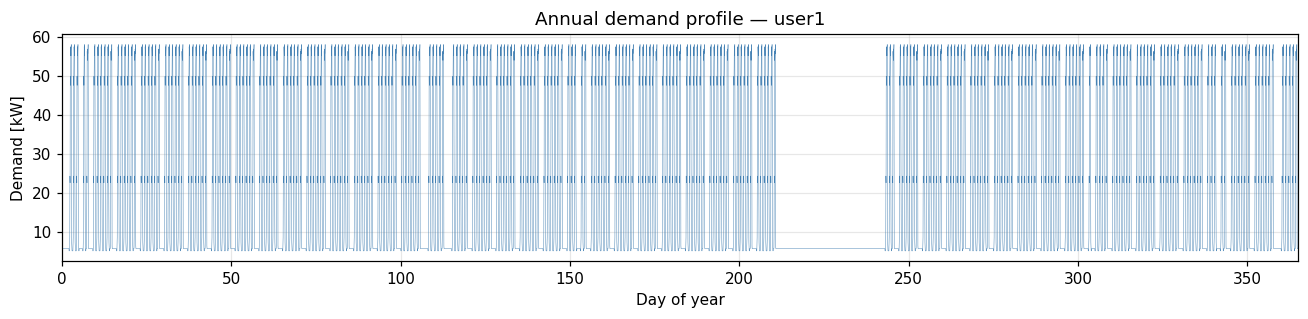

In [2]:
demand_path = Path("src/example_model/Rec1/Input/demand_qc_kw_el.csv")
demand_df = pd.read_csv(demand_path, sep=';')

prosumer_id = 'user1'
demand = demand_df[prosumer_id].values  # kW, quarter-hourly

print(f"Prosumer:        {prosumer_id}")
print(f"Time steps:      {len(demand)}  ({len(demand)*0.25/24:.0f} days)")
print(f"Peak demand:     {demand.max():.1f} kW")
print(f"Annual demand:   {demand.sum() * 0.25 / 1000:.1f} MWh")

fig, ax = plt.subplots(figsize=(12, 3))
days = np.arange(len(demand)) * 0.25 / 24
ax.plot(days, demand, linewidth=0.3, color='steelblue')
ax.set(xlabel='Day of year', ylabel='Demand [kW]', xlim=(0, 365))
ax.set_title(f'Annual demand profile — {prosumer_id}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## **Step 2 - Fetch Meteorological Data**

Irradiation and temperature from **PVGIS** for Rome, Italy. Data is cached locally after first download.

In [3]:
lat, lon = 41.9028, 12.4964
tilt, azimuth = 30, 0
time_step = 0.25

cache_dir = Path("src/example_model/Rec1/.pvgis_cache")
I_beam, I_skydiff, I_grounddiff, t_amb, wind_speed, theta = fetch_meteo(
    lat=lat, lon=lon, tilt=tilt, azimuth=azimuth,
    time_step_str='15min', time_step_hours=time_step, cache_dir=cache_dir)

meteo = dict(I_beam=I_beam, I_skydiff=I_skydiff, I_grounddiff=I_grounddiff,
             t_amb=t_amb, wind_speed=wind_speed, theta=theta)

print(f"Meteo: {len(I_beam)} timesteps")
print(f"Annual POA irradiation: {(I_beam.sum()+I_skydiff.sum()+I_grounddiff.sum())/1000:.0f} kWh/m2")

Meteo: 35040 timesteps
Annual POA irradiation: 4394 kWh/m2


---
## **Step 3 - Configure the Optimizer**

| Parameter | Value | Description |
|-----------|-------|-------------|
| `space_max` | 300 m2 | Available roof area |
| `utilization_factor` | 0.6 | Usable fraction |
| `specific_budget` | 2000 EUR/kWp | Budget cap (PV+BESS) |
| `n_series_pv` | 10 | Modules per string (~4 kWp) |
| `min_self_cons_ratio` | 0.05 | Min 5% self-consumption |

In [4]:
pv_economics = {
    'cap_cost': 1500, 'opex_cost': 40,
    'inverter_cost': 350, 'inverter_year': 10,
    'inc_rate': 0.5, 'inc_cap': 96000, 'inc_duration': 10,
}
bess_economics = {
    'cap_cost': 720, 'opex_cost': 20,
    'inc_rate': 0.5, 'inc_cap': 96000, 'inc_duration': 10,
}
prosumer_economics = {
    'tax_rate': 0.2, 'int_rate': 0.03,
    'price_buy': 130, 'price_sold': 104,
    'decay': 0.02, 'prod_degradation': 0.005,
}

common_kwargs = dict(
    demand=demand, meteo=meteo, time_step=time_step, tilt=tilt,
    n_series_pv=10, pv_economics=pv_economics,
    n_series_bess=1, bess_economics=bess_economics,
    space_max=300.0, utilization_factor=0.6, specific_budget=2000.0,
    min_self_cons_ratio=0.05, max_prod_dem_ratio=2.0,
    prosumer_economics=prosumer_economics, time_horizon=20,
    pop_size=80, n_gen=40, seed=42,
)

---
## **Step 4 - Run Optimization**

### Mode A: Self-Consumption
Maximizes absolute self-consumption [MWh/y] + NPV [EUR]. Best for **investment decisions** on a specific site.

In [5]:
opt_sc = ProsumerOptimizer(**common_kwargs, objective_mode='self_consumption')
opt_sc.summary()
results_sc = opt_sc.optimize()

  ProsumerOptimizer — self_consumption
  Time step:           0.25 h  (35040 steps)
  Annual demand:       180.83 MWh
  PV module:           400 W, 2.07 m²
  PV string:           10 modules → 4.00 kWp
  Net surface:         180.0 m²
  Max PV strings:      8  (32.0 kWp)
  BESS module:         2.560 kWh
  Max BESS parallel:   34  (87.0 kWh)
  Budget max:          64,051 €
  NSGA-II:             pop=80, gen=40
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       69 |      2 |  0.000000E+00 |  7.262737E+03 |             - |             -
     2 |      109 |      2 |  0.000000E+00 |  3.663541E+02 |  0.000000E+00 |             f
     3 |      149 |      2 |  0.000000E+00 |  0.0005264899 |  0.000000E+00 |             f
     4 |      189 |      2 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     5 |      229 |      3 |  0.000000E+00 |  0.000000E+00 |  0.8238185137 |         ideal
     6 |      269 |      4 |  0.000000E+00 

In [6]:
results_sc.drop_duplicates(subset=['n_parallel_pv','n_parallel_bess'])

,n_parallel_pv,n_parallel_bess,cap_pv_kW,cap_bess_kWh,capex_EUR,self_cons_MWh,NPV_EUR
0,8,8,32.03,21.98,63862.0,28.3421,13534.0
7,8,7,32.03,20.44,62755.0,28.2525,16352.0
14,8,6,32.03,17.62,60724.0,28.1640,19173.0
23,8,5,32.03,14.33,58359.0,28.0724,21988.0
33,8,4,32.03,10.75,55778.0,27.9777,24796.0
52,8,3,32.03,9.92,55178.0,27.8789,27595.0
58,8,2,32.03,7.18,53208.0,27.7797,30394.0
62,8,1,32.03,5.04,51667.0,27.6766,33185.0
67,8,0,32.03,0.62,48486.0,27.5342,35896.0


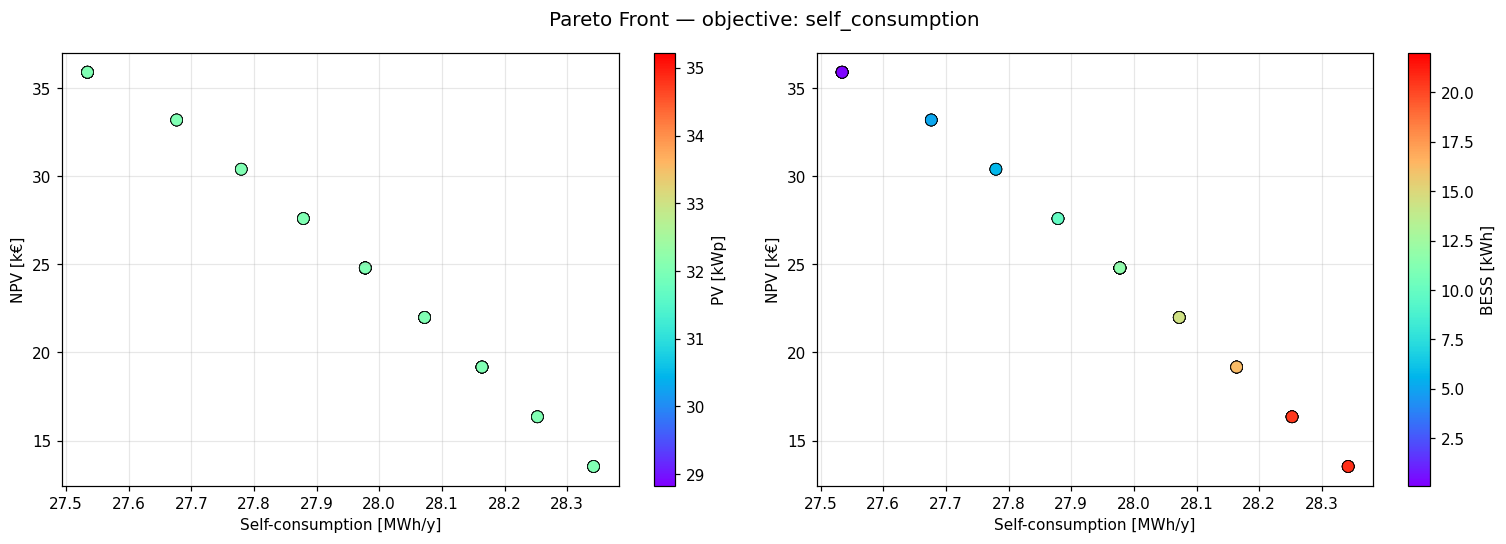

In [7]:
opt_sc.plot_pareto()
plt.show()

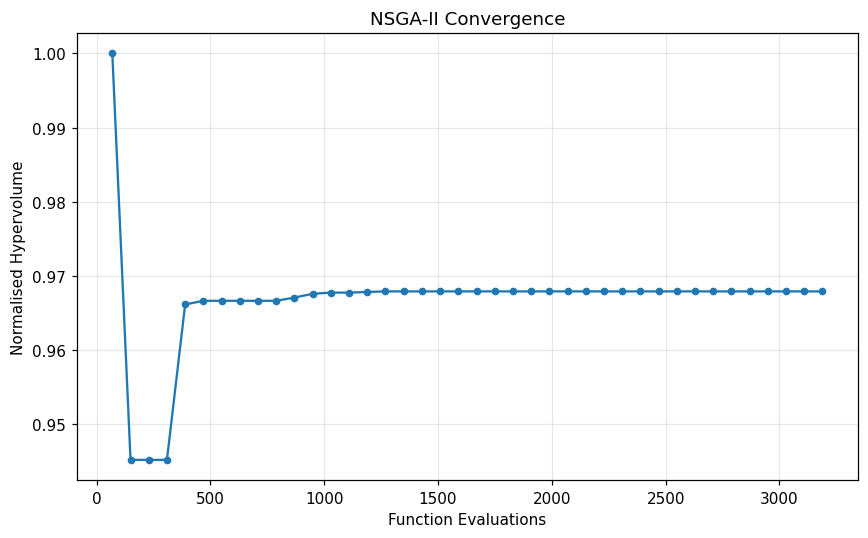

In [8]:
opt_sc.plot_convergence()
plt.show()

### Mode B: Self-Sufficiency
Maximizes self-sufficiency rate [0-1] + NPV [EUR]. Best for **parametric studies** or when a specific coverage target is set.

In [9]:
opt_ss = ProsumerOptimizer(**common_kwargs, objective_mode='self_sufficiency')
results_ss = opt_ss.optimize()

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       69 |      2 |  0.000000E+00 |  7.262737E+03 |             - |             -
     2 |      109 |      2 |  0.000000E+00 |  3.663541E+02 |  0.000000E+00 |             f
     3 |      149 |      2 |  0.000000E+00 |  0.0005264899 |  0.000000E+00 |             f
     4 |      189 |      2 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     5 |      229 |      3 |  0.000000E+00 |  0.000000E+00 |  0.8237628443 |         ideal
     6 |      269 |      4 |  0.000000E+00 |  0.000000E+00 |  0.0419561150 |             f
     7 |      309 |      4 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     8 |      349 |      4 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     9 |      389 |      4 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
    10 |      429 |      6 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f

In [10]:
results_ss.drop_duplicates(subset=['n_parallel_pv','n_parallel_bess'])

,n_parallel_pv,n_parallel_bess,cap_pv_kW,cap_bess_kWh,capex_EUR,self_sufficiency,NPV_EUR
0,8,8,32.03,21.82,63751.0,0.1563,13534.0
8,8,7,32.03,18.00,61001.0,0.1559,16352.0
19,8,6,32.03,15.75,59376.0,0.1554,19173.0
27,8,5,32.03,14.42,58420.0,0.1550,21988.0
38,8,4,32.03,11.11,56040.0,0.1545,24796.0
42,8,3,32.03,9.45,54844.0,0.1540,27595.0
51,8,2,32.03,6.02,52371.0,0.1535,30394.0
58,8,1,32.03,3.16,50316.0,0.1530,33185.0
73,8,0,32.03,0.14,48141.0,0.1523,35896.0


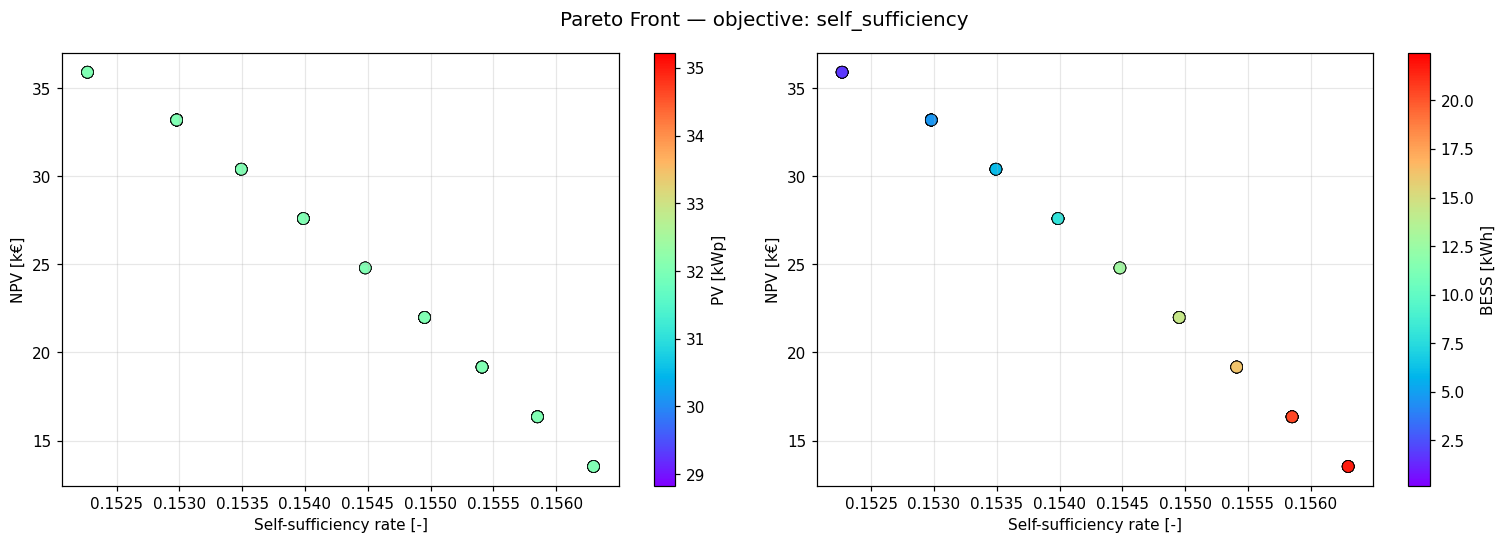

In [11]:
opt_ss.plot_pareto()
plt.show()

---
## **Step 5 - Select Optimal Solution**

We select a **best-compromise** solution from the Pareto front using the min-max normalisation (TOPSIS-like): the solution closest to the ideal point in normalised objective space.

In [12]:
# Select best-compromise from Mode A
F = opt_sc.pareto_F
F_norm = (F - F.min(axis=0)) / (F.max(axis=0) - F.min(axis=0) + 1e-12)
distances = np.sqrt((F_norm ** 2).sum(axis=1))
best_idx = np.argmin(distances)

best_X = opt_sc.pareto_X[best_idx]
n_pv_opt, n_bess_opt = int(best_X[0]), int(best_X[1])

cap_pv_opt = n_pv_opt * opt_sc.n_series_pv * opt_sc.cap_module_pv
cap_bess_opt = n_bess_opt * opt_sc.n_series_bess * opt_sc.cap_module_bess

print(f"Best-compromise solution:")
print(f"  PV:   {n_pv_opt} strings x {opt_sc.n_series_pv} modules = {cap_pv_opt:.1f} kWp")
print(f"  BESS: {n_bess_opt} parallel x {opt_sc.cap_module_bess:.2f} kWh = {cap_bess_opt:.1f} kWh")
print(f"  Self-consumption: {opt_sc.pareto_F[best_idx, 0]:.2f} MWh/y")
print(f"  NPV (incremental): {opt_sc.pareto_F[best_idx, 1]:,.0f} EUR")

Best-compromise solution:
  PV:   8 strings x 10 modules = 32.0 kWp
  BESS: 4 parallel x 2.56 kWh = 10.2 kWh
  Self-consumption: 27.98 MWh/y
  NPV (incremental): 24,796 EUR


---
## **Step 6 - Energy Performance of Optimal Solution**

Detailed simulation of the best-compromise configuration.

In [13]:
# Run detailed simulation
sim = opt_sc.simulate_solution(n_pv_opt, n_bess_opt)
en = sim['energy']
ann = sim['annual']

print(f"--- Annual Energy Balance ---")
print(f"  Production:       {ann['prod_MWh']:8.1f} MWh")
print(f"  Demand:           {ann['dem_MWh']:8.1f} MWh")
print(f"  Self-consumption: {ann['self_cons_MWh']:8.1f} MWh")
print(f"  Surplus (sold):   {ann['surplus_MWh']:8.1f} MWh")
print(f"  Purchased:        {ann['purchased_MWh']:8.1f} MWh")
print(f"  Self-sufficiency: {ann['self_suff_rate']:8.1%}")
print(f"  Self-cons. rate:  {ann['self_cons_rate']:8.1%}")

--- Annual Energy Balance ---
  Production:           31.8 MWh
  Demand:              180.8 MWh
  Self-consumption:     28.0 MWh
  Surplus (sold):        3.8 MWh
  Purchased:           152.9 MWh
  Self-sufficiency:    15.4%
  Self-cons. rate:     87.9%


### Seasonal Energy Profiles

Typical winter and summer weeks showing how PV production, demand, and BESS interact.

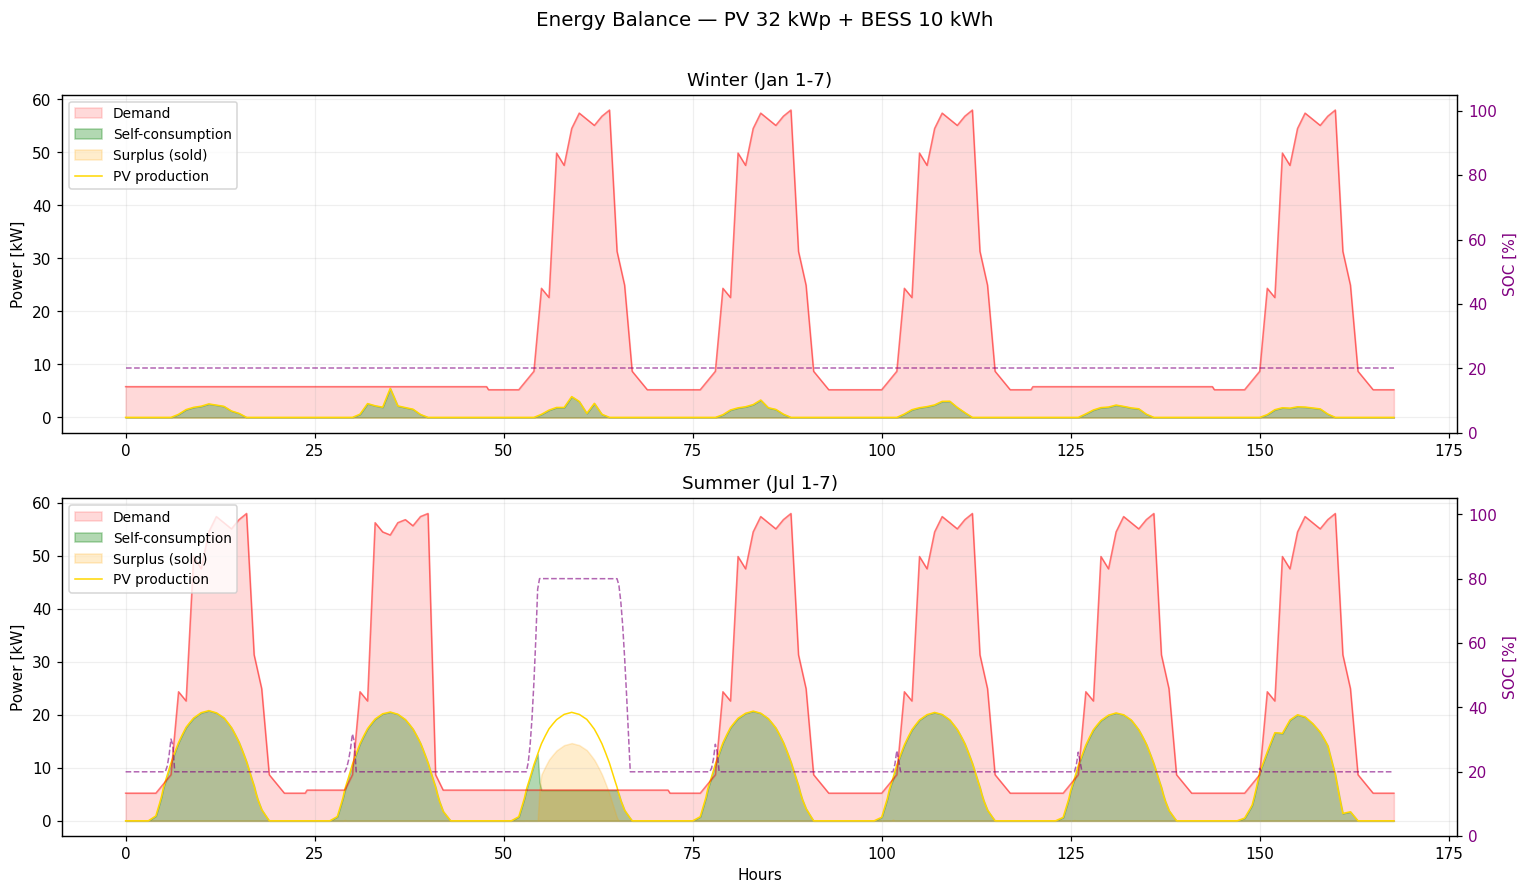

In [14]:
steps_per_day = int(24 / time_step)

# Winter: first week of January; Summer: first week of July
seasons = {
    'Winter (Jan 1-7)':  slice(0, 7 * steps_per_day),
    'Summer (Jul 1-7)':  slice(181 * steps_per_day, 188 * steps_per_day),
}

fig, axes = plt.subplots(len(seasons), 1, figsize=(14, 4 * len(seasons)), sharex=False)

for ax, (label, sl) in zip(axes, seasons.items()):
    hours = np.arange(len(en['prod'][sl])) * time_step
    ax.fill_between(hours, en['dem'][sl], alpha=0.15, color='red', label='Demand')
    ax.fill_between(hours, en['self_cons'][sl], alpha=0.3, color='green', label='Self-consumption')
    ax.fill_between(hours, en['surplus'][sl], alpha=0.2, color='orange', label='Surplus (sold)')
    ax.plot(hours, en['prod'][sl], linewidth=1, color='gold', label='PV production')
    ax.plot(hours, en['dem'][sl], linewidth=1, color='red', alpha=0.5)
    if n_bess_opt > 0:
        ax2 = ax.twinx()
        ax2.plot(hours, en['soc'][sl] * 100, linewidth=1, color='purple', alpha=0.6, linestyle='--', label='SOC')
        ax2.set_ylabel('SOC [%]', color='purple')
        ax2.set_ylim(0, 105)
        ax2.tick_params(axis='y', labelcolor='purple')
    ax.set(ylabel='Power [kW]', title=label)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Hours')
fig.suptitle(f'Energy Balance — PV {cap_pv_opt:.0f} kWp + BESS {cap_bess_opt:.0f} kWh', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

### Monthly Energy Balance

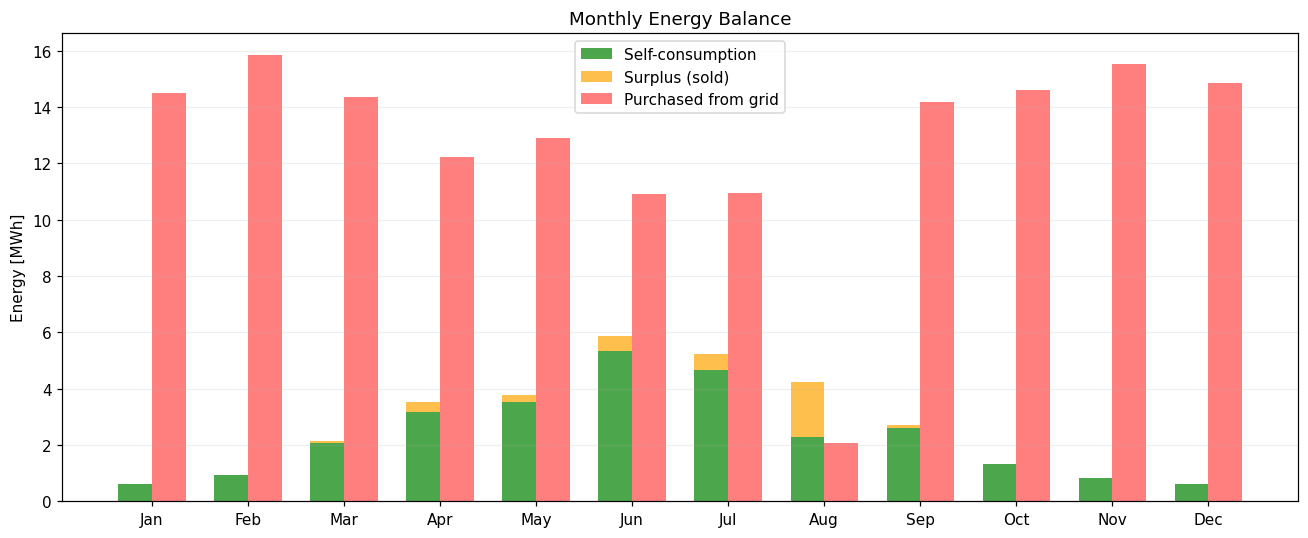

In [15]:
# Monthly aggregation
n_steps = len(en['prod'])
months = np.repeat(np.arange(12), n_steps // 12 + 1)[:n_steps]

monthly = pd.DataFrame({
    'month': months,
    'prod': en['prod'] * time_step / 1000,
    'self_cons': en['self_cons'] * time_step / 1000,
    'surplus': en['surplus'] * time_step / 1000,
    'purchased': en['unmet'] * time_step / 1000,
}).groupby('month').sum()

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
x = np.arange(12)
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, monthly['self_cons'], w, label='Self-consumption', color='green', alpha=0.7)
ax.bar(x - w/2, monthly['surplus'], w, bottom=monthly['self_cons'], label='Surplus (sold)', color='orange', alpha=0.7)
ax.bar(x + w/2, monthly['purchased'], w, label='Purchased from grid', color='red', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set(ylabel='Energy [MWh]', title='Monthly Energy Balance')
ax.legend()
ax.grid(True, alpha=0.2, axis='y')
fig.tight_layout()
plt.show()

---
## **Step 7 - Economic Performance**

Annual cashflow and cumulative cashflow over the investment horizon.

In [16]:
ec = sim['economics']
th = opt_sc.time_horizon
years = np.arange(th + 1)

print(f"--- Economic Summary ---")
print(f"  CAPEX:             {ec['capex']:>10,.0f} EUR")
print(f"  NPV (incremental): {ec['NPV_incremental']:>10,.0f} EUR")
print(f"  Payback period:    {ec['pbp']:>10.1f} years")

--- Economic Summary ---
  CAPEX:                 55,411 EUR
  NPV (incremental):     24,796 EUR
  Payback period:          -3.8 years


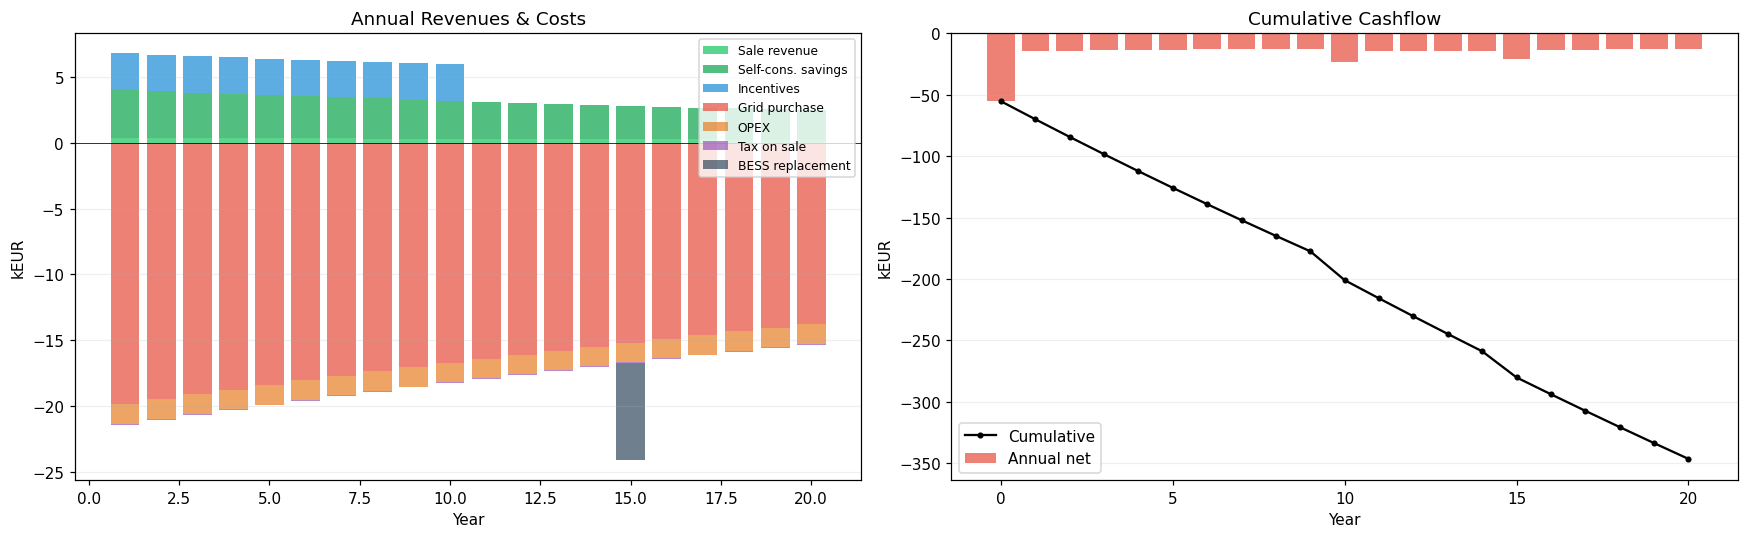

In [17]:
# Annual revenues and costs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# — Left: annual cashflow breakdown —
r_sale = ec['rev_from_sale'][1:]
r_sav  = ec['rev_savings'][1:]
r_inc  = ec['rev_incentives'][1:]
c_res  = ec['cost_resources'][1:]
c_opex = ec['cost_opex'][1:]
c_tax  = ec['cost_taxes_on_sale'][1:]
c_repl = ec['cost_bess_replacement'][1:]
yr = years[1:]

ax1.bar(yr, r_sale/1000, label='Sale revenue', color='#2ecc71', alpha=0.8)
ax1.bar(yr, r_sav/1000, bottom=r_sale/1000, label='Self-cons. savings', color='#27ae60', alpha=0.8)
ax1.bar(yr, r_inc/1000, bottom=(r_sale+r_sav)/1000, label='Incentives', color='#3498db', alpha=0.8)
ax1.bar(yr, -c_res/1000, label='Grid purchase', color='#e74c3c', alpha=0.7)
ax1.bar(yr, -c_opex/1000, bottom=-c_res/1000, label='OPEX', color='#e67e22', alpha=0.7)
ax1.bar(yr, -c_tax/1000, bottom=-(c_res+c_opex)/1000, label='Tax on sale', color='#9b59b6', alpha=0.7)
if c_repl.sum() > 0:
    ax1.bar(yr, -c_repl/1000, bottom=-(c_res+c_opex+c_tax)/1000, label='BESS replacement', color='#34495e', alpha=0.7)
ax1.axhline(0, color='k', linewidth=0.5)
ax1.set(xlabel='Year', ylabel='kEUR', title='Annual Revenues & Costs')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.2, axis='y')

# — Right: cumulative cashflow —
inflow = ec['rev_from_sale'] + ec['rev_savings'] + ec['rev_incentives'] + ec['rev_others']
outflow = ec['cost_resources'] + ec['cost_opex'] + ec['cost_taxes'] + ec['cost_taxes_on_sale'] + ec['cost_others'] + ec['cost_bess_replacement']
outflow[0] = ec['capex']
net_annual = inflow - outflow
cumulative = np.cumsum(net_annual)

ax2.bar(years, net_annual/1000, color=np.where(net_annual >= 0, '#2ecc71', '#e74c3c'), alpha=0.7, label='Annual net')
ax2.plot(years, cumulative/1000, 'k-o', markersize=3, linewidth=1.5, label='Cumulative')
ax2.axhline(0, color='k', linewidth=0.5)
ax2.set(xlabel='Year', ylabel='kEUR', title='Cumulative Cashflow')
ax2.legend()
ax2.grid(True, alpha=0.2, axis='y')

fig.tight_layout()
plt.show()

---
## **Step 8 - Environmental Performance**

CO2 emissions avoided and fossil fuel savings from displacing grid electricity with local PV production.

In [18]:
# Italian grid emission factors (ISPRA 2023)
CO2_FACTOR = 256  # gCO2/kWh

GRID_FUEL_MIX = {
    'natural_gas':  {'share': 0.42, 'efficiency': 0.50, 'toe_per_MWh': 0.086},
    'coal':         {'share': 0.04, 'efficiency': 0.38, 'toe_per_MWh': 0.086},
    'oil':          {'share': 0.03, 'efficiency': 0.38, 'toe_per_MWh': 0.086},
}

displaced_MWh = ann['self_cons_MWh'] + ann['surplus_MWh']  # total local production used or exported

co2_avoided_kg = displaced_MWh * 1000 * CO2_FACTOR / 1000  # kg CO2/year
co2_avoided_ton = co2_avoided_kg / 1000

fossil_savings = {}
for fuel, data in GRID_FUEL_MIX.items():
    fossil_savings[fuel] = displaced_MWh * data['share'] / data['efficiency'] * data['toe_per_MWh']
total_toe = sum(fossil_savings.values())

print(f"--- Environmental Performance (Year 1) ---")
print(f"  Displaced electricity:  {displaced_MWh:.1f} MWh")
print(f"  CO2 avoided:            {co2_avoided_ton:.2f} tCO2/year")
print(f"  CO2 avoided (20 years): {co2_avoided_ton * 20:.1f} tCO2")
print(f"  Fossil fuel savings:    {total_toe:.2f} toe/year")
for fuel, toe in fossil_savings.items():
    print(f"    {fuel:15s}: {toe:.3f} toe")

--- Environmental Performance (Year 1) ---
  Displaced electricity:  31.8 MWh
  CO2 avoided:            8.14 tCO2/year
  CO2 avoided (20 years): 162.9 tCO2
  Fossil fuel savings:    2.80 toe/year
    natural_gas    : 2.298 toe
    coal           : 0.288 toe
    oil            : 0.216 toe


### Summary Table

In [19]:
summary_data = {
    'PV capacity [kWp]': f"{sim['config']['cap_pv_kW']:.1f}",
    'BESS capacity [kWh]': f"{sim['config']['cap_bess_kWh']:.1f}",
    'Annual production [MWh]': f"{ann['prod_MWh']:.1f}",
    'Annual demand [MWh]': f"{ann['dem_MWh']:.1f}",
    'Self-consumption [MWh]': f"{ann['self_cons_MWh']:.1f}",
    'Self-sufficiency rate': f"{ann['self_suff_rate']:.1%}",
    'Self-consumption rate': f"{ann['self_cons_rate']:.1%}",
    'CAPEX [EUR]': f"{ec['capex']:,.0f}",
    'NPV incremental [EUR]': f"{ec['NPV_incremental']:,.0f}",
    'Payback [years]': f"{ec['pbp']:.1f}",
    'CO2 avoided [tCO2/y]': f"{co2_avoided_ton:.2f}",
    'Fossil savings [toe/y]': f"{total_toe:.2f}",
}

summary_df = pd.DataFrame.from_dict(summary_data, orient='index', columns=['Value'])
summary_df.index.name = 'Indicator'
summary_df

,Value
Indicator,
PV capacity [kWp],32.0
BESS capacity [kWh],10.2
Annual production [MWh],31.8
Annual demand [MWh],180.8
Self-consumption [MWh],28.0
Self-sufficiency rate,15.4%
Self-consumption rate,87.9%
CAPEX [EUR],"55,411"
NPV incremental [EUR],"24,796"


---
## **Step 9 - Sensitivity: Effect of Budget**

How does the budget constraint affect the Pareto front?

In [20]:
budgets = [1500, 2000, 3000]
colors = ['#e74c3c', '#3498db', '#2ecc71']
sens = {}

for b in budgets:
    kw = {**common_kwargs, 'specific_budget': b, 'objective_mode': 'self_consumption',
          'pop_size': 60, 'n_gen': 30}
    opt_tmp = ProsumerOptimizer(**kw)
    sens[b] = opt_tmp.optimize()
    print(f"Budget {b} EUR/kWp -> max {opt_tmp.budget_max:,.0f} EUR | {len(sens[b].drop_duplicates(subset=['n_parallel_pv','n_parallel_bess']))} solutions")

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       53 |      1 |  0.000000E+00 |  1.037895E+04 |             - |             -
     2 |       83 |      1 |  0.000000E+00 |  1.742713E+03 |  0.000000E+00 |             f
     3 |      113 |      1 |  0.000000E+00 |  0.0036723423 |  0.000000E+00 |             f
     4 |      143 |      2 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     5 |      173 |      4 |  0.000000E+00 |  0.000000E+00 |  1.0000000000 |         ideal
     6 |      203 |      8 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     7 |      233 |      6 |  0.000000E+00 |  0.000000E+00 |  0.1524821709 |         ideal
     8 |      263 |      8 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     9 |      293 |     21 |  0.000000E+00 |  0.000000E+00 |  0.3307682554 |         ideal
    10 |      323 |     33 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f

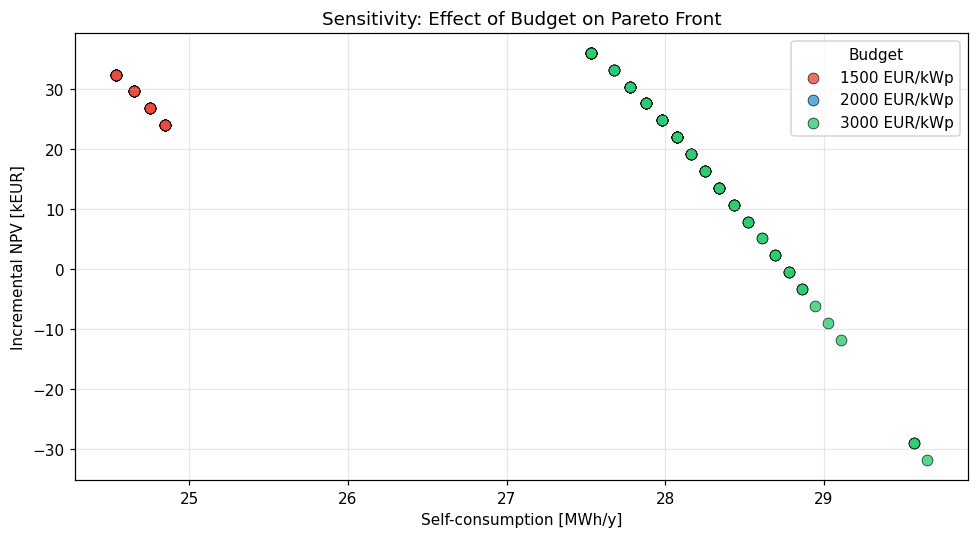

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
for b, c in zip(budgets, colors):
    df = sens[b]
    ax.scatter(df['self_cons_MWh'], df['NPV_EUR'] / 1000, s=50, c=c,
              edgecolors='k', linewidths=0.5, alpha=0.8, label=f'{b} EUR/kWp')
ax.set(xlabel='Self-consumption [MWh/y]', ylabel='Incremental NPV [kEUR]')
ax.set_title('Sensitivity: Effect of Budget on Pareto Front')
ax.legend(title='Budget')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

---
## **Summary**

| Parameter | Effect |
|-----------|--------|
| `space_max`, `utilization_factor` | Max PV size |
| `specific_budget` | Total CAPEX constraint |
| `min_self_cons_ratio` | Min local energy use |
| `pv_economics['cap_cost']` | PV market price |
| `bess_economics['cap_cost']` | Battery cost |
| `prosumer_economics['price_buy']` | Grid price (incentive for self-consumption) |
| `n_gen`, `pop_size` | Computation time vs solution quality |